# PoseBeat: Continuous Conditioned Music Generation

This notebook is the submission workbook. It keeps the important values visible, embeds only the training/evaluation curves needed for the presentation, documents the exact inference-ready weight artifacts, and includes code cells for five test-example inference and listening.


## 1. Setup

The notebook uses the repository files already produced under `outputs/`. It does not create a separate Markdown report or a helper `.py` file.


In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import pickle
import subprocess
import sys
import zipfile

import numpy as np
import pandas as pd
from IPython.display import Audio, Image, Markdown, display

# Works whether the notebook is launched from the repo root or from notebooks/.
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "outputs").exists() else CWD.parent
print(PROJECT_ROOT)


def read_json(relative_path: str):
    return json.loads((PROJECT_ROOT / relative_path).read_text())


def show_png(relative_path: str, width: int | None = None):
    display(Image(filename=str(PROJECT_ROOT / relative_path), width=width))


def dir_size_gb(path: Path) -> float | None:
    if not path.exists():
        return None
    total = sum(p.stat().st_size for p in path.rglob('*') if p.is_file())
    return total / (1024 ** 3)


## 2. External SharePoint/OneDrive Weights

The trained weight folders are shared through UCSD SharePoint/OneDrive. For this local run, the pipeline folders already exist under `outputs/`, so the notebook can use the local files directly.

| Model | Local folder used by this notebook | External folder link |
|---|---|---|
| Base final | `outputs/motion_to_music/pipeline_final/` | [Base checkpoint / artifact folder](https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgDsJDgOwZ2fT5pJCNW65mVHAaU-aEuxplmiatiZ3FB-QZ4?e=yzniwx) |
| High-res final | `outputs/motion_to_music_hires/pipeline_final/` | [Full high-res checkpoint / artifact folder](https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgCQTk7HvVuYS73UxMd8R8PTAY2jYtMtWuT-nIEG9NsAWTo?e=gxC8ml) |

If the local folders are missing on another machine, download the corresponding shared folder and place it at the local path shown above before running inference. The links are SharePoint/OneDrive folder links, not direct zip-download links.


In [ ]:
# UCSD SharePoint/OneDrive folders containing the shared trained artifacts.
BASE_PIPELINE_SHAREPOINT_URL = 'https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgDsJDgOwZ2fT5pJCNW65mVHAaU-aEuxplmiatiZ3FB-QZ4?e=yzniwx'
HIRES_PIPELINE_SHAREPOINT_URL = 'https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgCQTk7HvVuYS73UxMd8R8PTAY2jYtMtWuT-nIEG9NsAWTo?e=gxC8ml'

PIPELINE_SPECS = {
    'base': {
        'label': 'Base 256x256',
        'config': PROJECT_ROOT / 'configs' / 'motion_to_music.yaml',
        'pipeline': PROJECT_ROOT / 'outputs' / 'motion_to_music' / 'pipeline_final',
        'sharepoint_url': BASE_PIPELINE_SHAREPOINT_URL,
    },
    'hires': {
        'label': 'High-res 512x512',
        'config': PROJECT_ROOT / 'configs' / 'motion_to_music_hires.yaml',
        'pipeline': PROJECT_ROOT / 'outputs' / 'motion_to_music_hires' / 'pipeline_final',
        'sharepoint_url': HIRES_PIPELINE_SHAREPOINT_URL,
    },
}


def ensure_pipeline(model_name: str) -> Path:
    spec = PIPELINE_SPECS[model_name]
    pipeline = Path(spec['pipeline'])
    if (pipeline / 'model_index.json').exists():
        print(f'{model_name}: using local pipeline {pipeline}')
        return pipeline

    raise FileNotFoundError(
        f"{model_name} pipeline not found at {pipeline}. "
        f"Download the shared folder and place it there before running inference: {spec['sharepoint_url']}"
    )


for model_name, spec in PIPELINE_SPECS.items():
    path = Path(spec['pipeline'])
    print(model_name, 'pipeline exists:', (path / 'model_index.json').exists(), '|', path)
    print(model_name, 'shared folder:', spec['sharepoint_url'])


## 3. Exact Inference Artifacts And Checkpoints

PoseBeat does not use a single `best.pt` file at submission time. The inference-ready artifacts are saved Diffusers/AudioDiffusion pipeline folders.

| Model | Local inference artifact | External shared folder | Config | Approx size | Last raw checkpoint | Use in presentation |
|---|---|---|---|---:|---|---|
| Base 256x256 | `outputs/motion_to_music/pipeline_final/` | [Base checkpoint / artifact folder](https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgDsJDgOwZ2fT5pJCNW65mVHAaU-aEuxplmiatiZ3FB-QZ4?e=yzniwx) | `configs/motion_to_music.yaml` | 847 MB | step 27,000 checkpoint | Better FAD and genre KLD among the two final pipelines. |
| High-res 512x512 | `outputs/motion_to_music_hires/pipeline_final/` | [Full high-res checkpoint / artifact folder](https://ucsdcloud-my.sharepoint.com/:f:/g/personal/vmoparthi_ucsd_edu/IgCQTk7HvVuYS73UxMd8R8PTAY2jYtMtWuT-nIEG9NsAWTo?e=gxC8ml) | `configs/motion_to_music_hires.yaml` | 1.1 GB | step 110,000 checkpoint | Better beat coverage and beat hit, so this is the clearest conditioned-generation demo model. |

Raw checkpoint folders found locally:

| Folder | Size | Notes |
|---|---:|---|
| `outputs/motion_to_music/checkpoints/` | 56 GB | Base training snapshots. Not needed for notebook inference. |
| `outputs/motion_to_music_hires/checkpoints/` | 336 GB | High-res training snapshots. Not needed for notebook inference. |

For the main demo, use the high-res final pipeline because it follows motion beats best. The base final pipeline is still useful for the metric tradeoff discussion.


In [ ]:
artifact_rows = []
for model_name, spec in PIPELINE_SPECS.items():
    pipeline = Path(spec['pipeline'])
    artifact_rows.append({
        'model': spec['label'],
        'pipeline': pipeline.relative_to(PROJECT_ROOT),
        'exists': (pipeline / 'model_index.json').exists(),
        'size_gb': None if dir_size_gb(pipeline) is None else round(dir_size_gb(pipeline), 3),
        'config': spec['config'].relative_to(PROJECT_ROOT),
    })
pd.DataFrame(artifact_rows)


## 4. Dataset And Preprocessing

The actual DMD/PoseBeat pipeline here uses **AIST++** for the training/evaluation runs.


In [ ]:
dataset_summary = read_json('outputs/visualiser/dataset_overview/dataset_overview_summary.json')

aist = dataset_summary['aistpp']
mel = dataset_summary['mel_datasets']
conditions = dataset_summary['conditions']

pd.DataFrame([
    ['Raw AIST++ all.txt entries', aist['raw']['official_split_counts']['all.txt']],
    ['Local raw motion .pkl files', aist['raw']['raw_motion_pkls_present']],
    ['Crossmodal train / val / test base dances', '980 / 20 / 20'],
    ['Train sliced WAV files', aist['train_slices']],
    ['Train unique base dances', aist['train_unique_base_dances']],
    ['Test sliced WAV files', aist['test_slices']],
    ['Test unique base dances', aist['test_unique_base_dances']],
    ['CDCD eval WAV files', aist['cdcd_slices']],
    ['CDCD unique base dances', aist['cdcd_unique_base_dances']],
    ['Condition tensor shape', conditions['condition_shape']],
    ['Train condition pickle size (GB)', conditions['train_condition_pickle_gb']],
], columns=['Dataset fact', 'Value'])


### 4.1 Genre Coverage And Condition Tensor

The train/test data cover all ten AIST++ genre codes. The CDCD eval subset has 31 WAV files and does not include `WA/Waack`, so CDCD is useful for comparison but is not a fully genre-balanced test set.
Each 5-second example uses 150 motion frames at 30 fps. The model sees a normalized condition tensor with shape `[150, 370]`: 150 frames and 370 channels per frame.


In [ ]:
pd.read_csv(PROJECT_ROOT / 'outputs' / 'visualiser' / 'dataset_overview' / 'split_genre_counts.csv')


## 5. Training, Loss Curves, And Saved Weights

Both final pipelines were trained locally from the AIST++ processed data. The base model trained first; the high-res model trained after the high-res mel dataset was rebuilt.

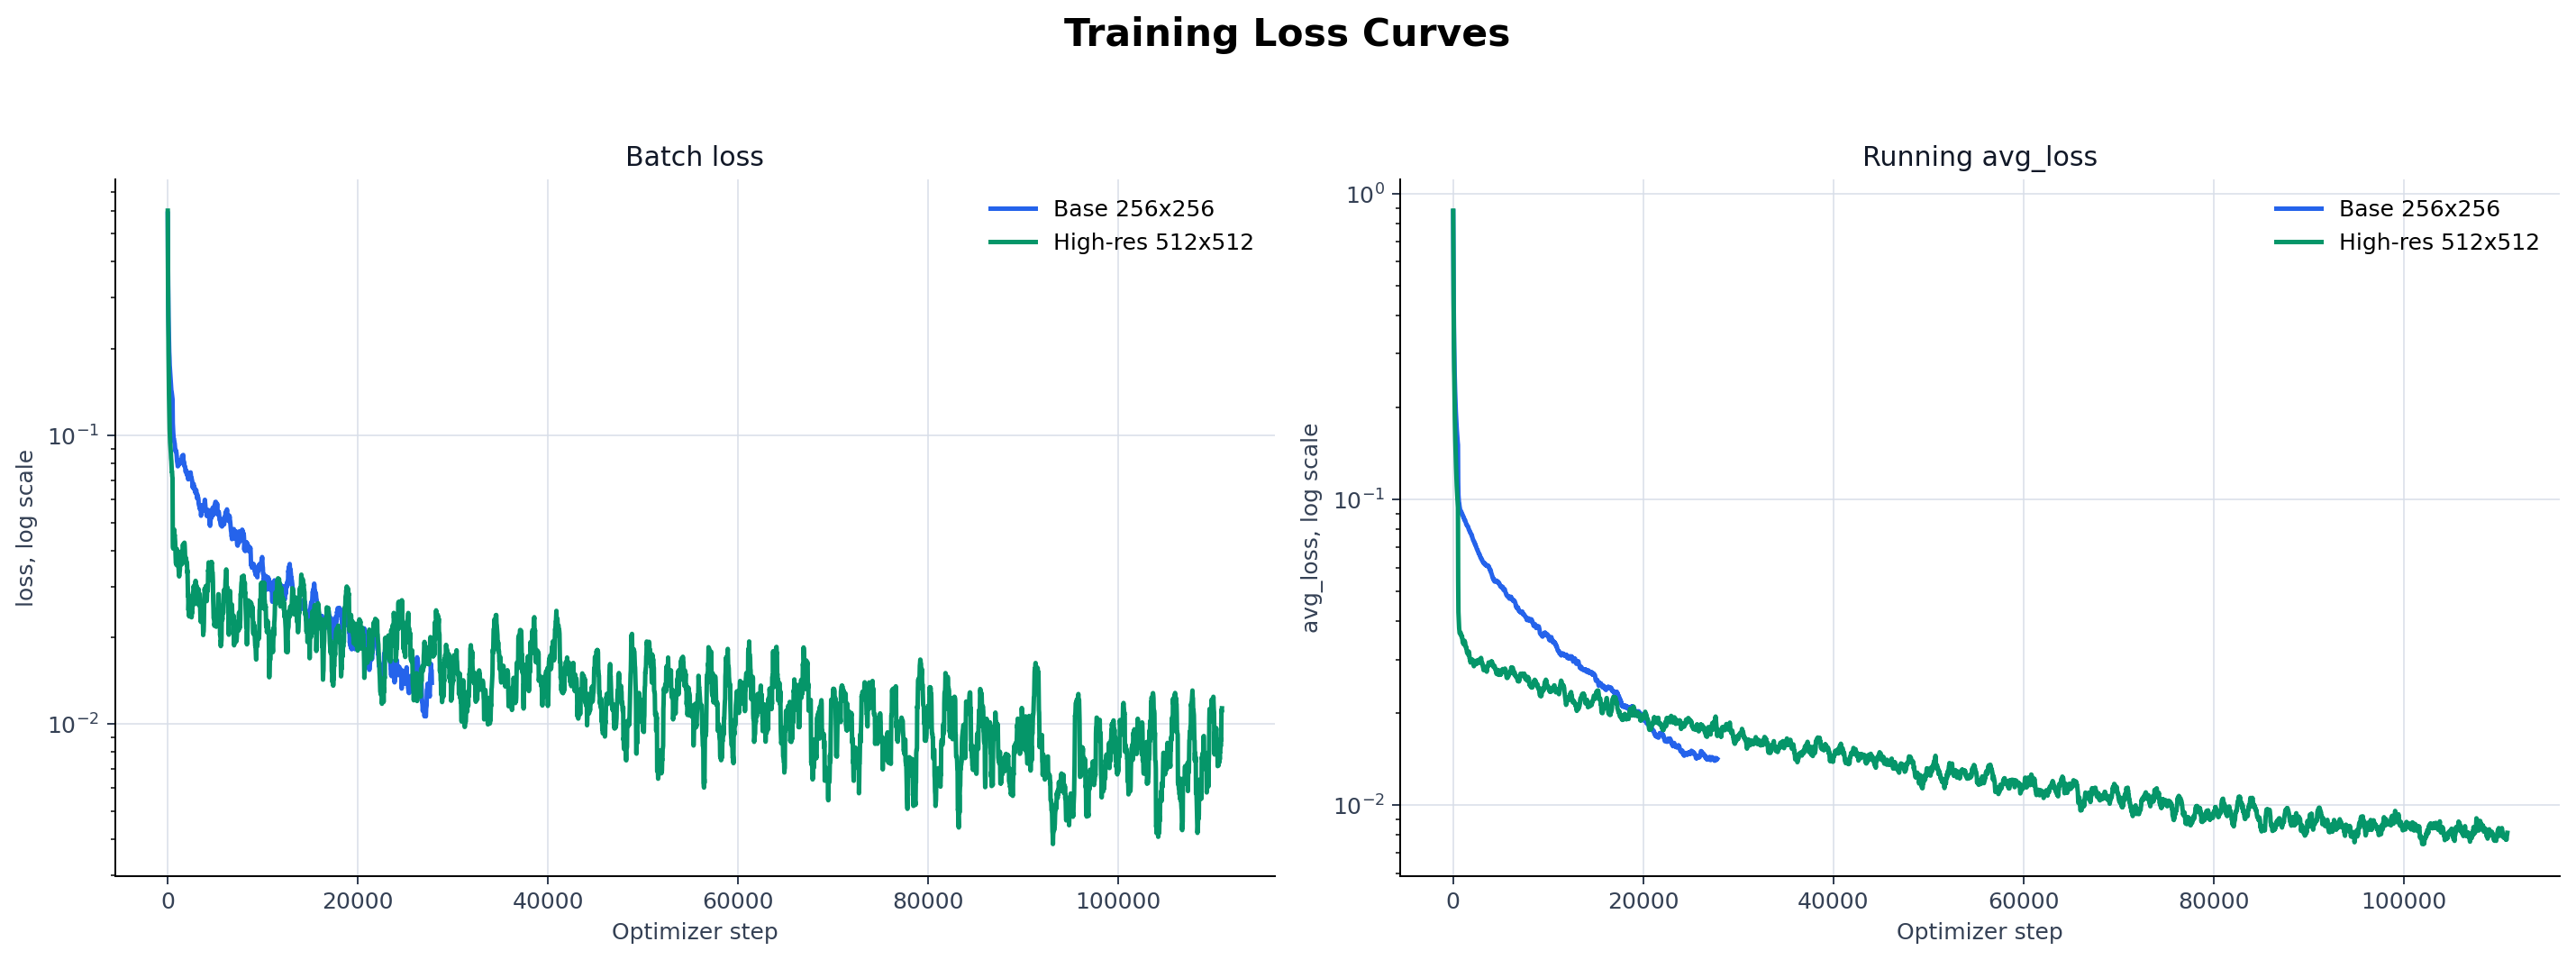

Training summary values are fixed here so they are visible in the submitted notebook without rerunning any parser:

| Model | Epochs | Final step | Training hours | Final avg loss | Best avg loss | Best avg-loss epoch | Notes |
|---|---:|---:|---:|---:|---:|---:|---|
| Base 256x256 | 100 | 27,800 | 6.118 | 0.014212 | 0.011292 | 99 | One clean run. |
| High-res 512x512 | 100 | 110,900 | 39.495 | 0.010552 | 0.004128 | 86 | Four aborted warm-up rows discarded before plotting. |


In [ ]:
training_summary = read_json('outputs/visualiser/training_curves/curve_summary.json')
rows = []
for key in ['base', 'hires']:
    item = training_summary['training'][key]
    rows.append({
        'model': item['label'],
        'final_epoch': item['final_epoch'],
        'final_step': item['final_step'],
        'duration_hours': item['duration_hours'],
        'final_avg_loss': item['final_avg_loss'],
        'best_avg_loss': item['min_avg_loss']['value'],
        'best_avg_loss_epoch': item['min_avg_loss']['epoch'],
        'detected_runs': item['detected_runs'],
        'discarded_restart_rows': item['discarded_restart_rows'],
    })
pd.DataFrame(rows)


## 6. Evaluation Curve

Evaluation uses the 31-file CDCD subset for generated outputs. The saved evaluation progression curve is embedded below.

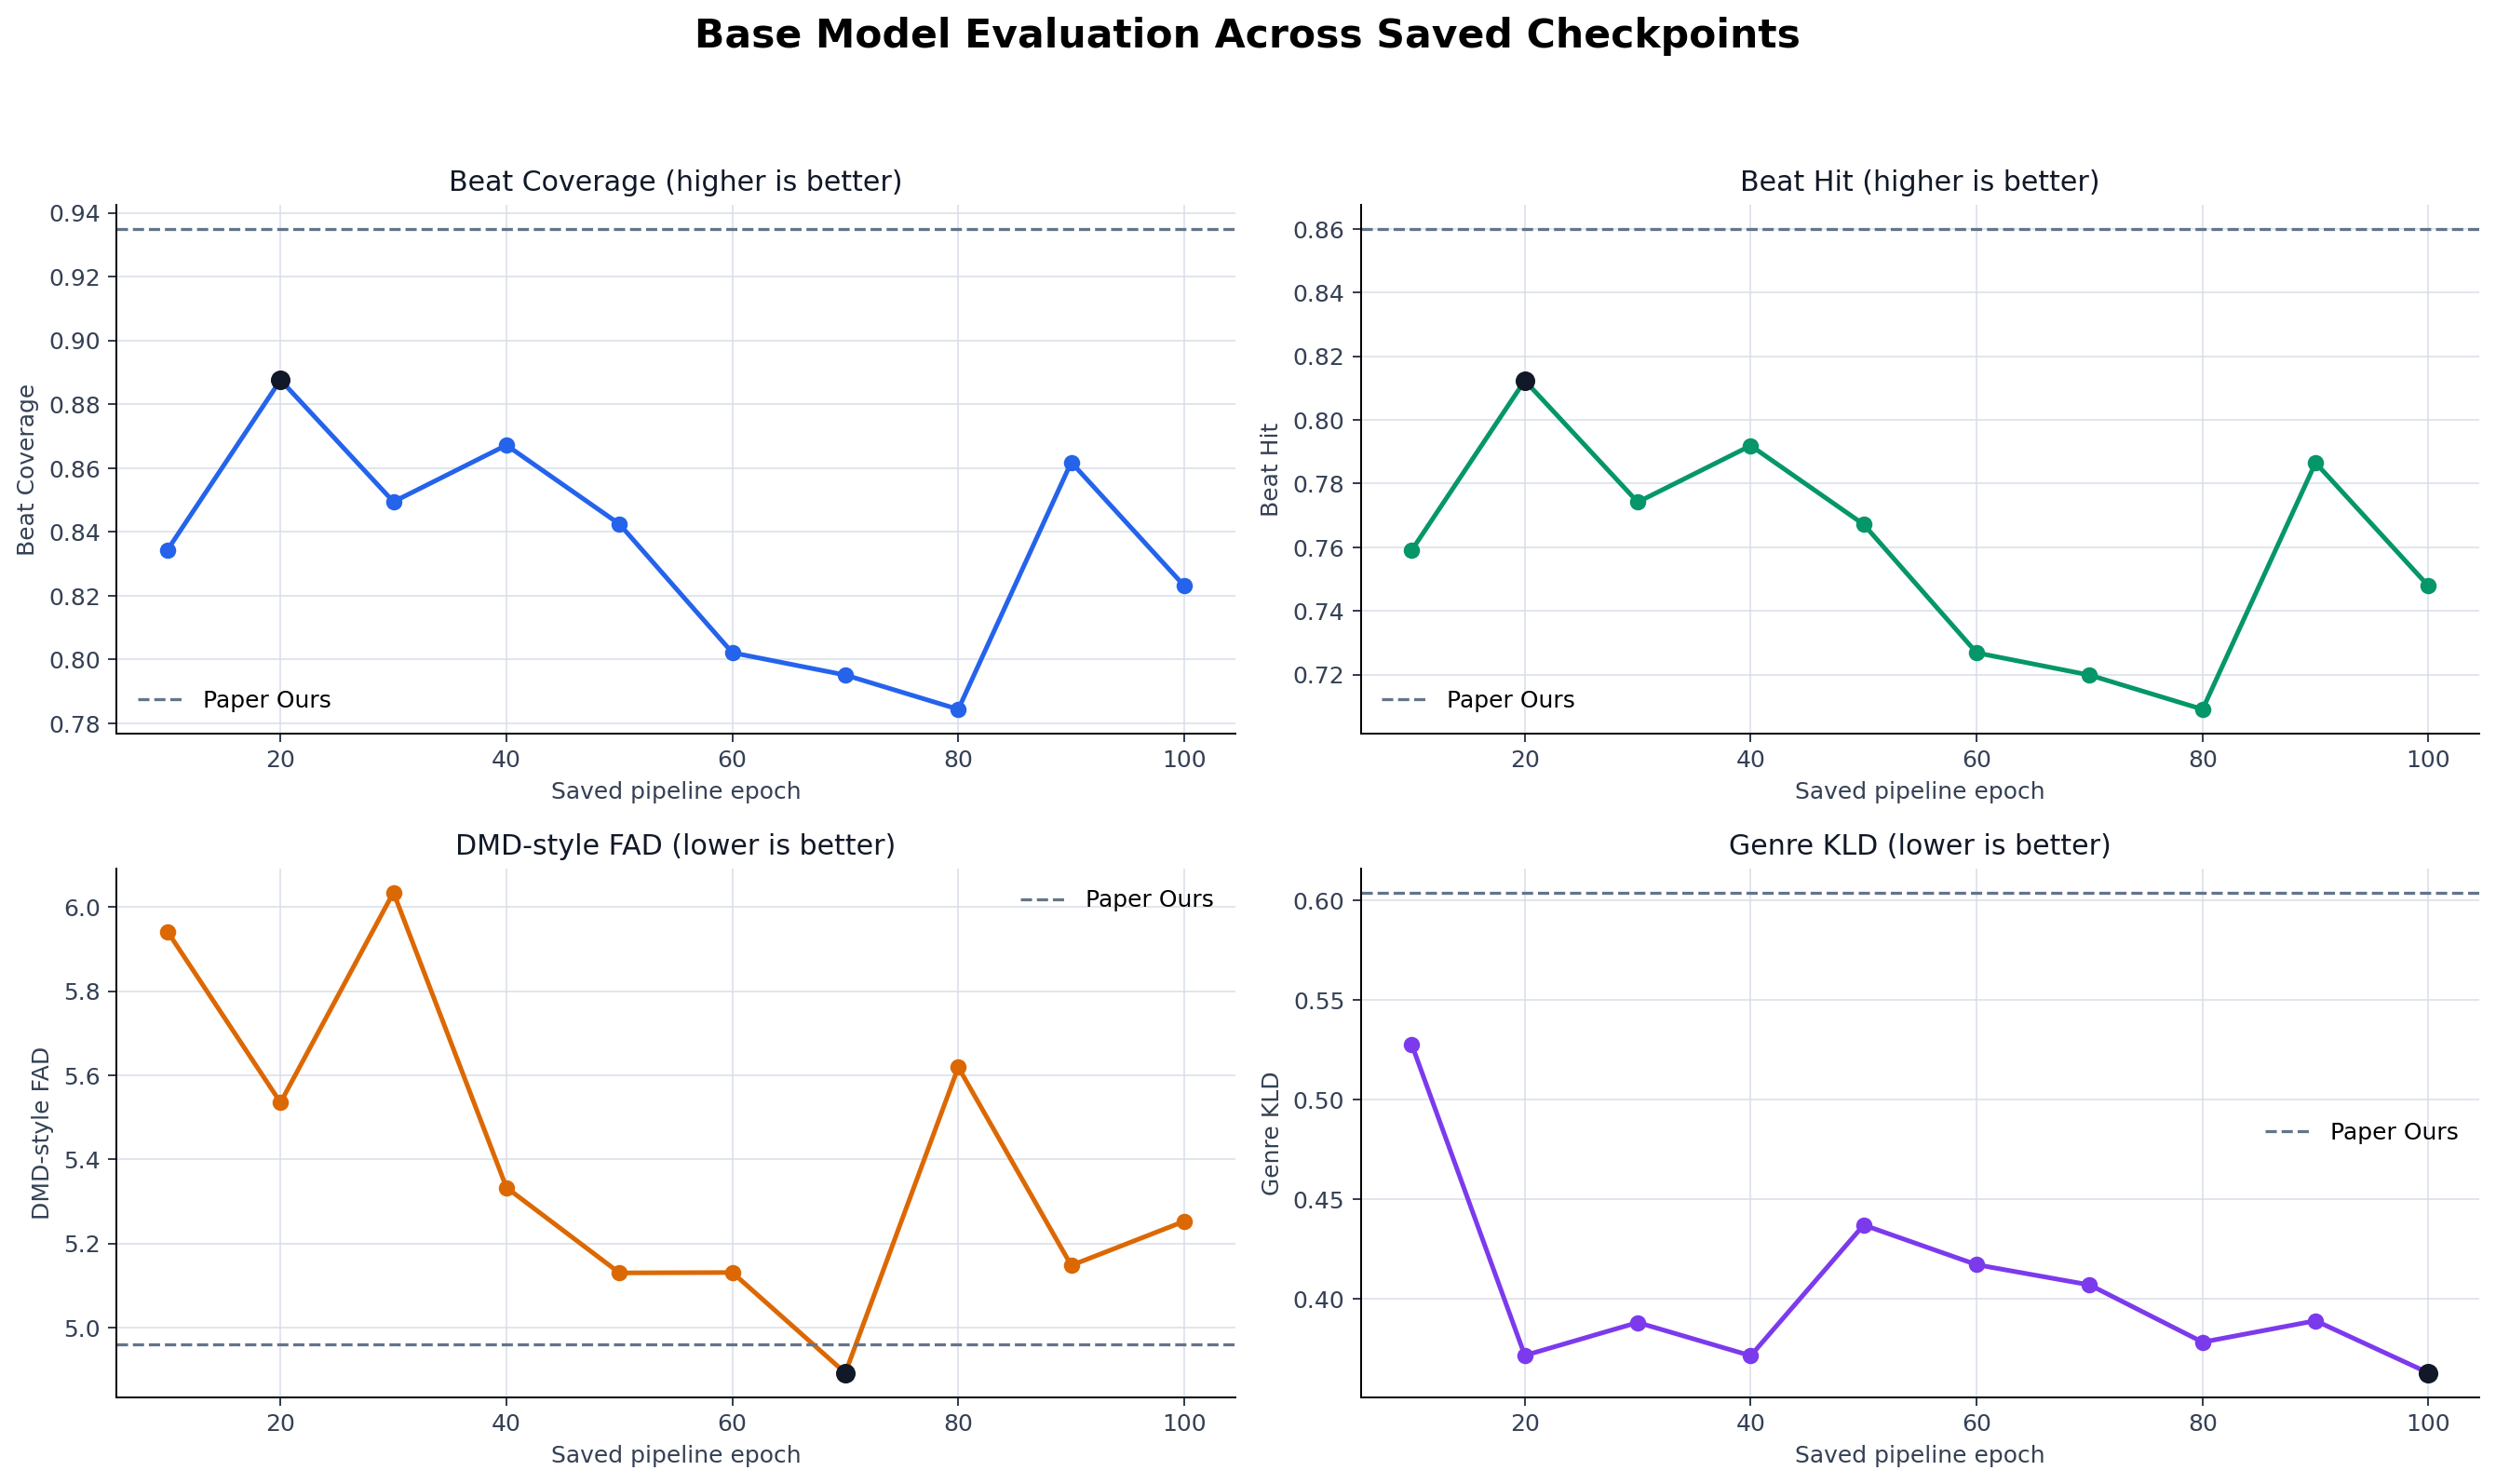


## 7. Five Test-Example Inference Demo

This section is ready to run inference from the saved model pipeline using code contained inside this notebook. It does **not** call any external repository `.py` files.

The five examples already generated for the submission are stored in:

```text
outputs/notebook_examples/reference/*.wav
outputs/notebook_examples/base_final/*.wav
outputs/notebook_examples/hires_final/*.wav
```

To regenerate them from the model, set `RUN_INFERENCE = True` in the next code cell. The generated WAVs will be written to:

```text
outputs/submission_notebook/five_test_examples/{MODEL}/*.wav
```

The inference code still needs the saved pipeline folder and the test motion-condition pickle, because those are model/data artifacts rather than Python source files.


In [ ]:
examples = pd.read_csv(PROJECT_ROOT / 'outputs' / 'notebook_examples' / 'example_index.csv')
examples


In [ ]:
MODEL_FOR_DEMO = 'hires'  # 'hires' for best beat alignment, or 'base' for lower final FAD/KLD.
RUN_INFERENCE = False     # Change to True to run generation from the saved pipeline.
DEVICE_FOR_DEMO = 'cuda:0'  # Change to 'cpu' if no CUDA GPU is available.
SEED_FOR_DEMO = 2391504374279719
ETA_FOR_DEMO = 0.0

TEST_MOTION_PICKLE = PROJECT_ROOT / 'data' / 'motion_to_music_aistpp_legacy_2026-05-26' / 'data_and_model' / 'conditions' / 'normalized_all_test_data_01.pkl'
DEMO_KEYS = examples['key'].tolist()
DEMO_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'submission_notebook' / 'five_test_examples' / MODEL_FOR_DEMO


def load_motion_encodings(path: Path) -> dict[str, np.ndarray]:
    with open(path, 'rb') as handle:
        encodings = pickle.load(handle)
    if not isinstance(encodings, dict):
        raise ValueError(f'Motion encoding file must contain a dict: {path}')
    return {str(key): np.asarray(value, dtype=np.float32) for key, value in encodings.items()}


def load_audio_diffusion_pipeline(model_dir: Path, device: str):
    try:
        from audiodiffusion.pipeline_audio_diffusion import AudioDiffusionPipeline
        pipe = AudioDiffusionPipeline.from_pretrained(model_dir, local_files_only=True)
    except Exception:
        from diffusers import DiffusionPipeline
        pipe = DiffusionPipeline.from_pretrained(model_dir, local_files_only=True)
    return pipe.to(device)


def audio_from_pipeline_output(output, pipe) -> tuple[int, np.ndarray]:
    mel = getattr(pipe, 'mel', None)
    sample_rate = mel.get_sample_rate() if mel is not None else 22050
    audio = output.audios

    try:
        import torch
        if isinstance(audio, torch.Tensor):
            audio = audio.detach().cpu().numpy()
    except ImportError:
        pass

    audio = np.asarray(audio)
    while audio.ndim > 1:
        audio = audio[0]
    return int(sample_rate), np.asarray(audio, dtype=np.float32)


def generate_one_wav(pipe, key: str, conditioning: np.ndarray, output_path: Path, device: str, seed: int, eta: float) -> Path:
    import scipy.io.wavfile
    import torch

    generator = torch.Generator(device=device).manual_seed(seed)
    encoding = torch.as_tensor(conditioning, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        output = pipe(generator=generator, eta=eta, encoding=encoding)

    sample_rate, audio = audio_from_pipeline_output(output, pipe)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    scipy.io.wavfile.write(output_path, sample_rate, np.clip(audio, -1.0, 1.0))
    return output_path


if RUN_INFERENCE:
    pipeline_dir = ensure_pipeline(MODEL_FOR_DEMO)
    motion_encodings = load_motion_encodings(TEST_MOTION_PICKLE)
    pipe = load_audio_diffusion_pipeline(pipeline_dir, DEVICE_FOR_DEMO)

    written = []
    for key in DEMO_KEYS:
        if key not in motion_encodings:
            raise KeyError(f'Motion key not found in {TEST_MOTION_PICKLE}: {key}')
        output_path = DEMO_OUTPUT_DIR / f'{key}.wav'
        written.append(generate_one_wav(
            pipe=pipe,
            key=key,
            conditioning=motion_encodings[key],
            output_path=output_path,
            device=DEVICE_FOR_DEMO,
            seed=SEED_FOR_DEMO,
            eta=ETA_FOR_DEMO,
        ))
    pd.DataFrame({'generated_wav': written})
else:
    print('Inference is disabled for the submitted notebook run.')
    print('Set RUN_INFERENCE = True to generate the five WAV files directly from notebook code.')
    print('Planned output directory:', DEMO_OUTPUT_DIR)
    print('Demo keys:', DEMO_KEYS)


### 7.1 Listening Examples

Each example has three WAV files:

| Audio | Meaning |
|---|---|
| Reference | Ground-truth AIST++ target music for comparison. It is not the model input. |
| Base final | Generated music from `outputs/motion_to_music/pipeline_final/`. |
| High-res final | Generated music from `outputs/motion_to_music_hires/pipeline_final/`. |

The actual model input for each output is the motion condition tensor for that key.


In [ ]:
for _, row in examples.iterrows():
    display(Markdown(f"### {row['key']} ({row['genre_code']})"))
    display(Markdown('Reference / ground truth'))
    display(Audio(str(PROJECT_ROOT / row['reference_wav'])))
    display(Markdown('Base final generated'))
    display(Audio(str(PROJECT_ROOT / row['base_final_wav'])))
    display(Markdown('High-res final generated'))
    display(Audio(str(PROJECT_ROOT / row['hires_final_wav'])))


## 8. Standalone Evaluation Check

The submitted notebook should not call external evaluator `.py` files. This section therefore reads and displays the already saved evaluation JSON files. The metric table above is the value to present; this cell is only a consistency check that the saved artifacts are present.


In [ ]:
SAVED_METRIC_FILES = {
    'base': PROJECT_ROOT / 'outputs' / 'motion_to_music' / 'eval_runs' / 'pipeline_final' / 'metrics_rerun_2026-06-02.json',
    'hires': PROJECT_ROOT / 'outputs' / 'motion_to_music_hires' / 'eval_runs' / 'pipeline_final' / 'metrics.json',
}

summary_for_paired_fad = read_json('outputs/visualiser/training_curves/curve_summary.json')['final_eval']

metric_rows = []
for model_name, path in SAVED_METRIC_FILES.items():
    row = {'model': model_name, 'metrics_file': path.relative_to(PROJECT_ROOT), 'exists': path.exists()}
    if path.exists():
        payload = json.loads(path.read_text())
        metrics = payload.get('metrics', payload)
        row.update({
            'beat_coverage': metrics.get('beat', {}).get('beat_coverage'),
            'beat_hit': metrics.get('beat', {}).get('beat_hit'),
            'fad_dmd_style': metrics.get('fad', {}).get('fad'),
            'paired_cdcd_fad': summary_for_paired_fad[model_name]['paired_cdcd_fad'],
            'genre_kld': metrics.get('genre', {}).get('genre_kld'),
        })
    metric_rows.append(row)

pd.DataFrame(metric_rows)
